In [1]:
#%%
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, FuncFormatter, LogFormatterSciNotation
import numpy as np
import math

In [2]:
"""
w14 plot for search initialization method comparison
verifies flatnav paper
"""

'\nw14 plot for search initialization method comparison\nverifies flatnav paper\n'

In [3]:
# for model
def loaddata(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'lp50':             arr[:, 5],
        'lp99':             arr[:, 6],
        'lave':             arr[:, 7],
        'dp50':             arr[:, 8],
        'dp99':             arr[:, 9],
        'dave':             arr[:, 10],
        'rp50':             arr[:, 11],
        'rp99':             arr[:, 12],
        'recall':           arr[:, 13],
    }

In [4]:
# plot full optimization matching results
datasets = {
    # 'dataname':     ("name", M)
    # 'deep':         ("deep-image-96-angular", 32),
    # 'gist':         ("gist-960-euclidean", 32),
    # 'glove-100':    ("glove-100-angular", 40),
    # 'glove-200':    ("glove-200-angular", 48),
    # 'mnist':        ("mnist-784-euclidean", 8),
    # 'nytimes':      ("nytimes-256-angular", 32),
    # 'sift':         ("sift-128-euclidean", 16),
    'randtest':     ("randtest10k", 4),
}

In [11]:
# function for plotting graphs to compare normal model, m5, m7, m8
def plot(datasets):
    # 1 dataset per set
    for dataset_name, (dataset_fullname, M) in datasets.items():

        # 1 param per graph
        # 1 param per graph
        metrics = {
            'l': "latency",
            'd': "distance_computation",
        }

        # 1 run per line, 1 color per line
        data = {            
            "hnsw":         loaddata(f"data/hnsw-si-reg-{dataset_fullname}.txt"),
            "hnswgre":      loaddata(f"data/hnsw-si-gre-{dataset_fullname}.txt"),
            "hnswini50":    loaddata(f"data/hnsw-si-ini50-{dataset_fullname}.txt"),
            "hnswini100":   loaddata(f"data/hnsw-si-ini100-{dataset_fullname}.txt"),
            "hnswini200":   loaddata(f"data/hnsw-si-ini200-{dataset_fullname}.txt"),
            "hnswini400":   loaddata(f"data/hnsw-si-ini400-{dataset_fullname}.txt"),
        }

        linecolors = [
            "#d1001c",      #reg
            "#db0bc6",      #gre
            "#23948c",      #ini50
            "#235e94",      #ini100
            "#3d328a",      #ini200
            "#a40bdb",      #ini400
        ]

        # 3 types of lines, p50, p99, ave, 1 property setting for each
        lineweights = [0.7, 0.7, 0.2]
        linestyles = ['-', ':', '-']
        percentiles = [ 'ave' ] # 'p50', 'p99'
        marker = 'x'

        # set x 
        xkey = "recall"
        
        # for each plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        for (key,value), ax in zip(metrics.items(), (ax1, ax2)):

            # for each run = each line
            for (dataname, dataset), color in zip(data.items(), linecolors):
                for linestyle, percentile, lineweight in zip(linestyles, percentiles, lineweights):

                    # define x array
                    x = dataset[xkey]
                    #define y array
                    ykey = f"{key}{percentile}"

                    y = dataset[ykey]

                    # plot
                    ax.plot(x, y, marker=marker, color=color, label=f'{dataname}-{percentile}', alpha=lineweight, linestyle=linestyle)

            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

        # save/show
        fig.tight_layout()
        fig.show()
        # fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

C:\Users\Katherine\AppData\Local\Temp\ipykernel_20196\3312062580.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


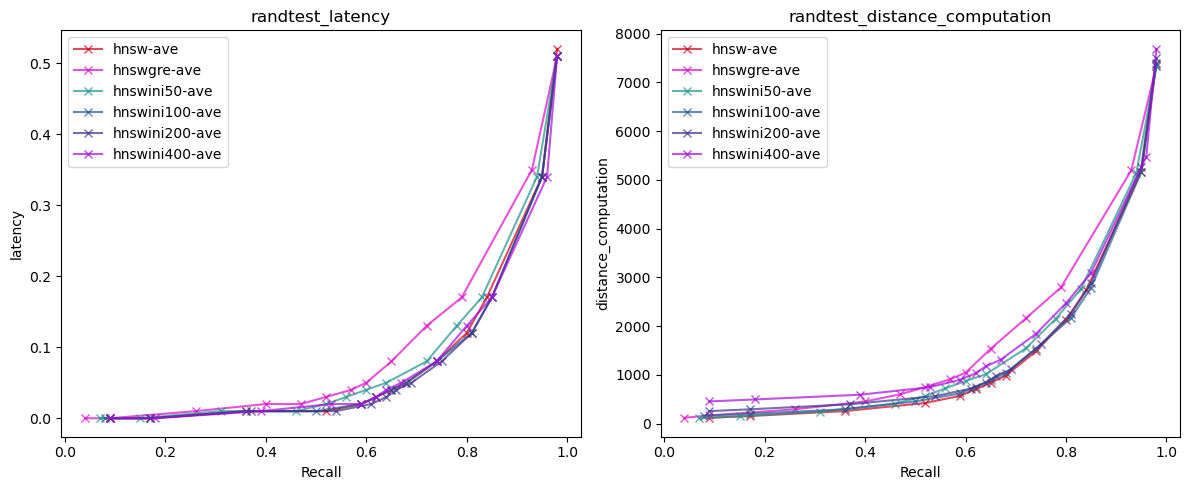

In [12]:
plot(datasets)